In [11]:
%run Extract_Loads_Energy_Use.ipynb

In [ ]:
%run Meter_Data_Analysis.ipynb

In [78]:
#units
tons_per_watt = 0.0002843451
kwh_per_j = 2.77778e-7
kWh_per_therm = 29.3001
kbtu_per_kwh = 3.412
steam_htg_value = 970
year = 2025 

In [79]:
therms_per_j = 9.48043e-9
therms_per_kbtu = .01

In [ ]:
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')

In [36]:
elec_data_filepath = ('C:/Users/aallen/OneDrive - NREL/Scalable TENs/')
string_path_test = 'C:/Users/aallen/Documents/NBK_Bremerton/run/createbar_scenario_847_mod_epd_fuel_type/'
dir_path_test = Path('C:/Users/aallen/Documents/NBK_Bremerton/run/createbar_scenario_847_mod_epd_fuel_type/') #replace with path 
dir_path_orig = Path('C:/Users/aallen/Documents/NBK_Bremerton/run/createbar_scenario_mod_properties_v4/')
dir_path_orig_01c = Path('C:/Users/aallen/Documents/NBK_Bremerton/run/createbar_scenario_mod_properties')
id_test = "a20539dd-f643-4532-847a-4fd15663f1bc"
id_test_2 = '01c99d14-837d-487e-944c-d761eb786a5c'
id_847 = '272b516a-4686-413b-8c5e-fa17c2877992'
dir_path_850 = Path('C:/Users/aallen/Documents/NBK_Bremerton/run/createbar_scenario_b850/')
id_850 = '0976a4a1-3812-480e-ba04-29acc0688713'

In [102]:
#read in elec data
elec_data = pd.read_excel(elec_data_filepath + 'AMI_aggregated_single_building_Markup_AA_v2(elec).xlsx', engine='openpyxl', sheet_name='Monthly_pivots')

In [103]:
elec_data = elec_data[1:]
elec_data.columns = elec_data.iloc[0]
elec_data  = elec_data[1:]
elec_data = elec_data[:13]

In [115]:
##B434##

In [76]:
#read in 434 gas data
gas_data_434 = pd.read_csv('C:/Users/aallen/Documents/NBK_Bremerton/run/createbar_scenario_mod_properties_v6/a20_mod_dhw/inMeter.csv')

In [91]:
#process NG data for 434
start_dt = date(year, 1,1)
end_dt = date(year+1, 1,1)
dates = pd.date_range(start=start_dt, end=end_dt, freq='15min')
dates = dates[:-1]
working_df = gas_data_434['NaturalGas:Facility [J](TimeStep)'].to_frame().set_index(dates)
monthly_df_434 = working_df.resample('MS').sum()*therms_per_j

(0.0, 420.0)

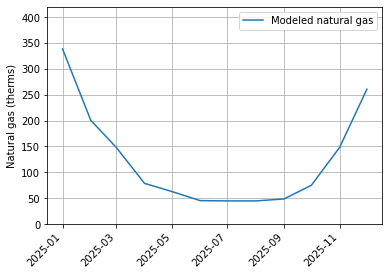

In [109]:
plt.plot(monthly_df_434['NaturalGas:Facility [J](TimeStep)'], label='Modeled natural gas')
ax = plt.gca()
plt.grid()
plt.ylabel('Natural gas (therms)')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.xticks(rotation=45, ha='right') 
plt.legend()
plt.ylim(0, 350*1.2)

In [107]:
#process elec for 434
elec_load_a20 = calc_load_profile_spec(dir_path_orig, id_test, 'Electricity')[0]
elec_sum_a20 = calc_load_profile_spec(dir_path_orig, id_test, 'Electricity')[1]
month_sums_a20_elec = calc_monthly_sums(analysis_year, timesteps_per_hr, elec_load_a20, 1, 'Electricity')[2]
#add in metered for 434
month_sums_a20_elec['metered'] = elec_data['Sum of B434'][0:12].values

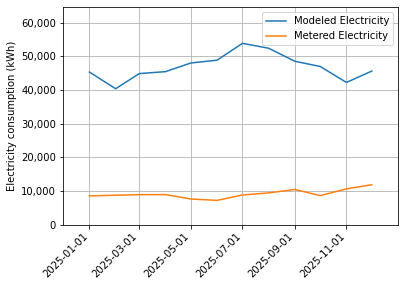

In [108]:
#plot monthly elec 
#B434
plot_monthly(id_test, month_sums_a20_elec, 'Electricity')
plt.plot(month_sums_a20_elec['metered'], label='Metered Electricity')
plt.legend()

In [116]:
##B661##

In [113]:
#661 post proc data
b661_post_proc = pd.read_csv('C:/Users/aallen/Documents/NBK_Bremerton/run/createbar_scenario_mod_properties_v6/01c_mod_vent/in_v3/run/eplusout.csv')

In [114]:
b661_post_proc['dhw_sum_rev_j'] = b661_post_proc.filter(like='Water Use Equipment Heating Energy').sum(axis=1)

In [ ]:
b661_htg_load = calc_thermal_load_profile_spec_post_proc_file(b661_post_proc)['htg']

In [118]:
#post proc space heating from 661
working_df_661_space_htg = calc_thermal_load_profile_spec_post_proc_file(b661_post_proc)['htg'].to_frame().set_index(dates)
monthly_df_661_space_htg = working_df_661_space_htg.resample('MS').sum()*wh_to_lbs/4

#DHW from b661
b661_post_proc['dhw_sum_rev_j'] = b661_post_proc.filter(like='Water Use Equipment Heating Energy').sum(axis=1)
working_df_661_dhw = b661_post_proc['dhw_sum_rev_j'].to_frame().set_index(dates)
monthly_df_661_dhw = working_df_661_dhw.resample('MS').sum()*wh_to_lbs*1000*kwh_per_j

#total
b661_htg_modeled = monthly_df_661_space_htg['htg'] + monthly_df_661_dhw['dhw_sum_rev_j'] #QC'd and roughly confirmed this value, its in lbs
#name columns for plotting 
b661_htg_modeled=b661_htg_modeled.to_frame(name='htg')

In [128]:
#psot proc b661
working_df_661 = b661_post_proc['Electricity:Facility [J](TimeStep)'].to_frame().set_index(dates)
monthly_df_661_elec = working_df_661.resample('MS').sum()*kwh_per_j

In [133]:
#set metered elec values B661
monthly_df_661_elec['metered'] = elec_data['B661_alt'][0:12].values
monthly_df_661_elec['metered_2024'] = elec_data['B661_alt_2024'][0:12].values

(0.0, 120000.0)

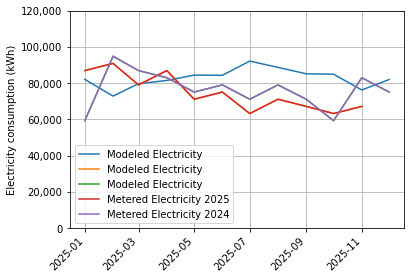

In [135]:
#plot monthly elec B661
ax = plt.gca()
plt.plot(monthly_df_661_elec, label= 'Modeled Electricity')
plt.plot(monthly_df_661_elec['metered'], label='Metered Electricity 2025')
plt.plot(monthly_df_661_elec['metered_2024'], label = 'Metered Electricity 2024')
plt.ylabel('Electricity consumption (kWh)')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.legend()
plt.xticks(rotation=45, ha='right') 
plt.grid()
plt.ylim(0, 120000)

In [204]:
#Calculate for B661
b661_steam_month_metered = b661_steam_month[0]

b661_steam_month_metered.index = b661_steam_month_metered.index.to_period('M').to_timestamp()

b661_steam_month_metered_mod = b661_steam_month_metered #manually qc'd january value 

#taking average of 2 months before and after to replace inaccurate metered value 

b661_steam_month_metered_mod[3]= (b661_steam_month_metered_mod[2] + b661_steam_month_metered_mod[4])/2

b661_steam_month_metered_mod[11] = 823172 - 815056 #manually setting to Dec '24 value '



C:\Users\aallen\AppData\Local\Temp\1\ipykernel_43552\771445741.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b661_steam_month_metered_mod[3]= (b661_steam_month_metered_mod[2] + b661_steam_month_metered_mod[4])/2
C:\Users\aallen\AppData\Local\Temp\1\ipykernel_43552\771445741.py:10: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  b661_steam_month_metered_mod[3]= (b661_steam_month_metered_mod[2] + b661_steam_month_metered_mod[4])/2
C:\Users\aallen\AppData\Local\Temp\1\ipykernel_43552\771445741.py:12: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys w

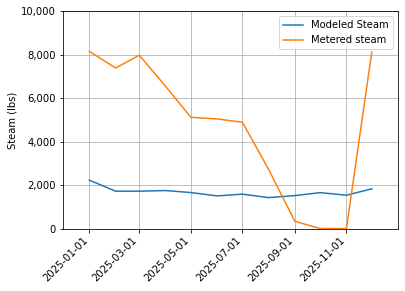

In [206]:
#adding a column w/o the extreme value for plotting

plot_monthly(id_test_2, b661_htg_modeled, "Steam")

#plot_monthly(id_test_2, b661_steam_month_metered_mod, "Steam")
plt.plot(b661_steam_month_metered_mod, label='Metered steam')
plt.ylim(0, 10000)
plt.legend()

In [ ]:
pk_clg_tons_01c = thermal_prof_01c['clg'].max()*tons_per_watt

In [ ]:
##B847##

In [143]:
#read in 847 gas data
gas_data_847 = pd.read_csv(string_path_test + '272b516a-4686-413b-8c5e-fa17c2877992/016_default_feature_reports/default_feature_reports.csv')

In [144]:
#process NG data for 847
start_dt = date(year, 1,1)
end_dt = date(year+1, 1,1)
dates = pd.date_range(start=start_dt, end=end_dt, freq='15min')
dates = dates[:-1]
working_df = gas_data_847['NaturalGas:Facility(kBtu)'].to_frame().set_index(dates)
monthly_df_847 = working_df.resample('MS').sum()*therms_per_kbtu

In [147]:
#gas data 847
b847_ng_profile = calc_load_profile_spec(dir_path_test, id_847, 'Natural Gas')[0]

In [149]:
#elec data for 847
elec_load_847 = calc_load_profile_spec(dir_path_test, id_847, 'Electricity')[0]
elec_sum_847 = calc_load_profile_spec(dir_path_test, id_847, 'Electricity')[1]
month_sums_847_elec = calc_monthly_sums(analysis_year, timesteps_per_hr, elec_load_847, 1, 'Electricity')[2]

In [150]:
#modifying to account for gas and elec combined to represent all elec bldg 
month_sums_847_elec['mod_elec'] = month_sums_847_elec['272b516a-4686-413b-8c5e-fa17c2877992'] + kWh_per_therm*monthly_df_847['NaturalGas:Facility(kBtu)']*0.8

(array([20089., 20148., 20209., 20270., 20332., 20393.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

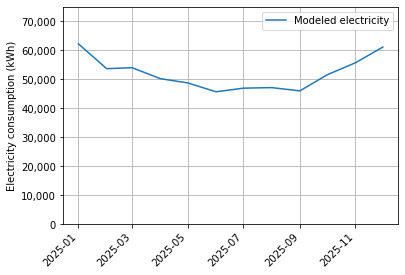

In [151]:
plt.plot(month_sums_847_elec['mod_elec'], label='Modeled electricity')
ax = plt.gca()
plt.grid()
plt.ylabel('Electricity consumption (kWh)')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.legend()
plt.ylim(0, 62500*1.2)
plt.xticks(rotation=45, ha='right') 

In [ ]:
##B850##

In [184]:
#850 data
#thermal profile
thermal_prof_850 = calc_thermal_load_profile_spec(dir_path_850, id_850)
month_sums_850_steam = calc_monthly_sums(analysis_year, timesteps_per_hr, thermal_prof_850['htg'].to_frame(),  wh_to_lbs, 'Steam')[2]
elec_load_850 = calc_load_profile_spec(dir_path_850, id_850, 'Electricity')[0]
elec_sum_850 = calc_load_profile_spec(dir_path_850, id_850, 'Electricity')[1]
month_sums_850_elec = calc_monthly_sums(analysis_year, timesteps_per_hr, elec_load_850, 1, 'Electricity')[2]
#modifying to take the 2024 value for missing Dec 25 value, and scaling Nov 24 by 2 since half of month missing 
month_sums_850_elec['metered_mod']=elec_data['Sum of B850_alt'][0:12].values
month_sums_850_elec['metered']=elec_data['Sum of B850'][0:12].values
month_sums_850_elec['metered_mod'][10]=elec_data['Sum of B850'][12]*2

C:\Users\aallen\AppData\Local\Temp\1\ipykernel_43552\4105309150.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  month_sums_850_elec['metered_mod'][10]=elec_data['Sum of B850'][12]*2
C:\Users\aallen\AppData\Local\Temp\1\ipykernel_43552\4

(0.0, 1750000.0)

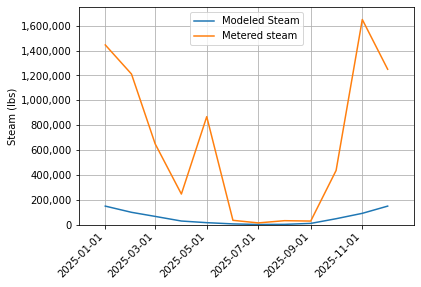

In [164]:
plot_monthly(id_850, month_sums_850_steam, 'Steam')
plt.plot(b850_steam_month, label='Metered steam')
plt.legend()
plt.ylim(0, 1.75*10**6)

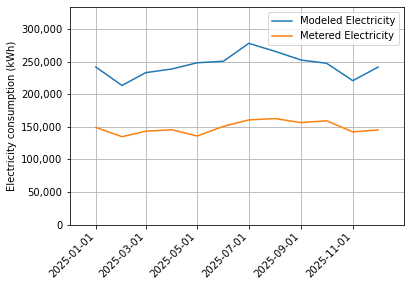

In [187]:
plot_monthly(id_850, month_sums_850_elec, 'Electricity')
plt.plot(month_sums_850_elec['metered_mod'], label='Metered Electricity')
plt.legend()

In [ ]:
##end of individual bldg calcs 

In [339]:
floor_area_sheet = pd.read_excel(elec_data_filepath + 'Proposed bldg list screening.xlsx', engine='openpyxl', sheet_name = 'Sheet2', skiprows=[0,2])

In [340]:
#Method to calculate EUIs
#Method assumes electricity in kWh, gas in therms, and steam in lbs 
def calc_eui(floor_area, energy_use, col_name):
    init_eui = energy_use/floor_area
    eui = 0 
    if 'elec' in col: 
        eui = init_eui * kbtu_per_kwh
    elif 'steam' in col: 
         eui = init_eui * steam_htg_value/1000
    elif 'gas' in col: 
          eui = init_eui/therms_per_kbtu
    return eui 


In [341]:
floor_area_sheet = floor_area_sheet.set_index('Bldg No. ')



In [342]:
bldgs_eui_calc = [434, 661, 847, 850] #set bldg numbers for EUI calcs to look up floor area 

In [343]:
#no meter data for 847; all electric bldg 
#set modeled and metered data for EUI calcs
metered_elec_use = [month_sums_a20_elec['metered'].sum(), monthly_df_661_elec['metered_2024'].sum(), 0, month_sums_850_elec['metered_mod'].sum()] #using 24 for 661 since 25 missing dec
modeled_steam_use = [0, b661_htg_modeled['htg'].sum(), 0, month_sums_850_steam['htg'].sum()]
metered_steam_use  = [0, b661_steam_month_metered_mod.sum(), 0, b850_steam_month.sum()]
modeled_elec_use = [month_sums_a20_elec['a20539dd-f643-4532-847a-4fd15663f1bc'].sum(), monthly_df_661_elec['Electricity:Facility [J](TimeStep)'].sum(), month_sums_847_elec['mod_elec'].sum(), month_sums_850_elec['0976a4a1-3812-480e-ba04-29acc0688713'].sum()]
modeled_gas_use = [monthly_df_434['NaturalGas:Facility [J](TimeStep)'].sum(), 0, 0, 0] #therms
metered_gas_use = [0,0,0,0]

In [344]:
#combine energy use data into df
energy_use_data = pd.DataFrame({"Metered_elec": metered_elec_use, "Modeled_elec": modeled_elec_use, "Metered_steam": metered_steam_use,"Modeled_steam": modeled_steam_use, "Modeled_gas": modeled_gas_use, "Metered_gas":metered_gas_use})

In [345]:
energy_use_data.index = bldgs_eui_calc

In [346]:
energy_use_data

,Metered_elec,Modeled_elec,Metered_steam,Modeled_steam,Modeled_gas,Metered_gas
434,1.094110e+05,5.623449e+05,0.0,0.000000,1495.666031,0
661,9.168500e+05,9.941955e+05,56252.0,20092.871290,0.000000,0
847,0.000000e+00,6.224088e+05,0.0,0.000000,0.000000,0
850,1.785535e+06,2.932551e+06,7860660.0,657085.307832,0.000000,0


In [347]:
for row in energy_use_data.itertuples():
    idx = row.Index
    
    # Safely check if the index exists in the smaller df2
    if idx in floor_area_sheet.index:
        energy_use_data.at[idx, 'Floor_area'] = floor_area_sheet.at[idx, 'Floor area (SF)']

In [348]:
energy_use_data

,Metered_elec,Modeled_elec,Metered_steam,Modeled_steam,Modeled_gas,Metered_gas,Floor_area
434,1.094110e+05,5.623449e+05,0.0,0.000000,1495.666031,0,38443.0
661,9.168500e+05,9.941955e+05,56252.0,20092.871290,0.000000,0,33964.0
847,0.000000e+00,6.224088e+05,0.0,0.000000,0.000000,0,40452.0
850,1.785535e+06,2.932551e+06,7860660.0,657085.307832,0.000000,0,231734.0


In [349]:
for col in energy_use_data.columns:
    if "Floor" not in col:
        energy_use_data[f"{col}_eui"] = energy_use_data.apply(
        lambda x: calc_eui(x['Floor_area'], x[col], col), 
        axis=1
    )

modeled_eui_cols = [col for col in energy_use_data.columns if ('Modeled' in col) and ('eui' in col)]
metered_eui_cols = [col for col in energy_use_data.columns if ('Metered' in col) and ('eui' in col)]
        
energy_use_data['modeled_eui_tot'] = energy_use_data[modeled_eui_cols].sum(axis=1)

energy_use_data['metered_eui_tot'] = energy_use_data[metered_eui_cols].sum(axis=1)





In [329]:
energy_use_data.to_csv('C:/Users/aallen/OneDrive - NREL/Scalable TENs/eui_outputs.csv')